# Get genome-wide dependencies in E. coli

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
import gzip
import shutil
import pyranges as pr
import glob
import os
from pyfaidx import Fasta

In [2]:
data_path = 'data'

## Getting annotated non-coding regions

In [3]:
gtf_path = os.path.join(data_path, "Escherichia_coli_str_k_12_substr_mg1655_gca_000005845.ASM584v2.59.gtf")
fasta_path = os.path.join(data_path, "Escherichia_coli_str_k_12_substr_mg1655_gca_000005845.ASM584v2.dna.toplevel.fa")

gtf_pr = pr.read_gtf(gtf_path)
gtf_df = gtf_pr.df.copy()


In [4]:
sequences = Fasta(fasta_path)

# Create a dictionary to hold chromosome lengths
chromosome_lengths = {seq: len(sequences[seq]) for seq in sequences.keys()}


In [5]:
chromosome_lengths

{'Chromosome': 4641652}

In [6]:
chromosome_lengths['Chromosome']/1000

4641.652

In [7]:
gtf_cds_pr = pr.PyRanges(gtf_df[(gtf_df.Feature == 'CDS')|(gtf_df.Feature == 'start_codon') | (gtf_df.Feature == 'stop_codon')].copy())
gtf_cds_pr

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_name,gene_source,gene_biotype,transcript_id,transcript_name,transcript_source,transcript_biotype,tag,exon_number,exon_id,protein_id
0,Chromosome,ena,CDS,4112966,4113263,.,+,0,b3922,yiiS,ena,protein_coding,AAC76904,yiiS-1,ena,protein_coding,Ensembl_canonical,1,NaN,AAC76904
1,Chromosome,ena,start_codon,4112966,4112969,.,+,0,b3922,yiiS,ena,protein_coding,AAC76904,yiiS-1,ena,protein_coding,Ensembl_canonical,1,NaN,NaN
2,Chromosome,ena,stop_codon,4113263,4113266,.,+,0,b3922,yiiS,ena,protein_coding,AAC76904,yiiS-1,ena,protein_coding,Ensembl_canonical,1,NaN,NaN
3,Chromosome,ena,CDS,2413469,2414669,.,+,0,b2296,ackA,ena,protein_coding,AAC75356,ackA-1,ena,protein_coding,Ensembl_canonical,1,NaN,AAC75356
4,Chromosome,ena,start_codon,2413469,2413472,.,+,0,b2296,ackA,ena,protein_coding,AAC75356,ackA-1,ena,protein_coding,Ensembl_canonical,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12715,Chromosome,ena,start_codon,3300755,3300758,.,-,0,b3156,yhbS,ena,protein_coding,AAC76190,yhbS-1,ena,protein_coding,Ensembl_canonical,1,NaN,NaN
12716,Chromosome,ena,stop_codon,3300254,3300257,.,-,0,b3156,yhbS,ena,protein_coding,AAC76190,yhbS-1,ena,protein_coding,Ensembl_canonical,1,NaN,NaN
12717,Chromosome,ena,CDS,3803060,3804137,.,-,0,b3628,waaB,ena,protein_coding,AAC76652,waaB-1,ena,protein_coding,Ensembl_canonical,1,NaN,AAC76652
12718,Chromosome,ena,start_codon,3804134,3804137,.,-,0,b3628,waaB,ena,protein_coding,AAC76652,waaB-1,ena,protein_coding,Ensembl_canonical,1,NaN,NaN


In [8]:
gtf_cds_merged_pr = gtf_cds_pr.merge(strand=False) # merge all overlapping CDS regions. Disregard strand
gtf_cds_merged_pr

,Chromosome,Start,End
0,Chromosome,189,255
1,Chromosome,336,2799
2,Chromosome,2800,5020
3,Chromosome,5233,5530
4,Chromosome,5682,6459
...,...,...,...
3483,Chromosome,4636006,4638120
3484,Chromosome,4638177,4639530
3485,Chromosome,4639589,4640306
3486,Chromosome,4640401,4640542


In [9]:
chromosome_df = pd.DataFrame({'Chromosome': list(chromosome_lengths.keys()), 'Start': 0, 'End': list(chromosome_lengths.values())})
chromosome_df

,Chromosome,Start,End
0,Chromosome,0,4641652


In [10]:
chromosome_pr = pr.PyRanges(chromosome_df)
chromosome_pr

,Chromosome,Start,End
0,Chromosome,0,4641652


In [11]:
nc_regions_pr = chromosome_pr.subtract(gtf_cds_merged_pr)
nc_regions_pr

,Chromosome,Start,End
0,Chromosome,0,189
1,Chromosome,255,336
2,Chromosome,2799,2800
3,Chromosome,5020,5233
4,Chromosome,5530,5682
...,...,...,...
3484,Chromosome,4638120,4638177
3485,Chromosome,4639530,4639589
3486,Chromosome,4640306,4640401
3487,Chromosome,4640542,4640941


In [12]:
nc_regions_df = nc_regions_pr.df
nc_regions_df['length'] = nc_regions_df.End - nc_regions_df.Start
nc_regions_df

,Chromosome,Start,End,length
0,Chromosome,0,189,189
1,Chromosome,255,336,81
2,Chromosome,2799,2800,1
3,Chromosome,5020,5233,213
4,Chromosome,5530,5682,152
...,...,...,...,...
3484,Chromosome,4638120,4638177,57
3485,Chromosome,4639530,4639589,59
3486,Chromosome,4640306,4640401,95
3487,Chromosome,4640542,4640941,399


In [13]:
#several regions between genes only have 1bp length. I checked some examples and it is really the case according to the ensemble annotation ex. open link https://bacteria.ensembl.org/Escherichia_coli_str_k_12_substr_mg1655_gca_000005845/Location/View?db=core;g=b0028;r=Chromosome:2700-2900;t=AAC73139
nc_regions_df[nc_regions_df['length']==1]

,Chromosome,Start,End,length
2,Chromosome,2799,2800,1
23,Chromosome,26275,26276,1
69,Chromosome,90092,90093,1
73,Chromosome,103153,103154,1
280,Chromosome,370275,370276,1
426,Chromosome,556873,556874,1
515,Chromosome,670572,670573,1
612,Chromosome,819293,819294,1
702,Chromosome,944031,944032,1
799,Chromosome,1086519,1086520,1


In [14]:
nc_regions_df['length'].value_counts().sort_index().iloc[:30]

length
1     47
2     57
3     55
4     32
5     14
6     16
7     26
8     16
9     59
10    59
11    50
12    40
13    22
14    37
15    24
16    22
17    19
18    19
19    14
20    24
21    17
22    18
23    14
24    25
25     9
26    15
27    14
28    12
29    11
30    14
Name: count, dtype: int64

In [15]:
nc_regions_df = nc_regions_df[nc_regions_df['length']>10].copy()
nc_regions_df

,Chromosome,Start,End,length
0,Chromosome,0,189,189
1,Chromosome,255,336,81
3,Chromosome,5020,5233,213
4,Chromosome,5530,5682,152
5,Chromosome,6459,6528,69
...,...,...,...,...
3484,Chromosome,4638120,4638177,57
3485,Chromosome,4639530,4639589,59
3486,Chromosome,4640306,4640401,95
3487,Chromosome,4640542,4640941,399


In [16]:
pr.PyRanges(nc_regions_df).merge().df.iloc[:,1:].to_csv(os.path.join(data_path, 'ecoli_dms_processed_data/nc_regions_ecoli.bed'), sep='\t',  index=False)

<Axes: >

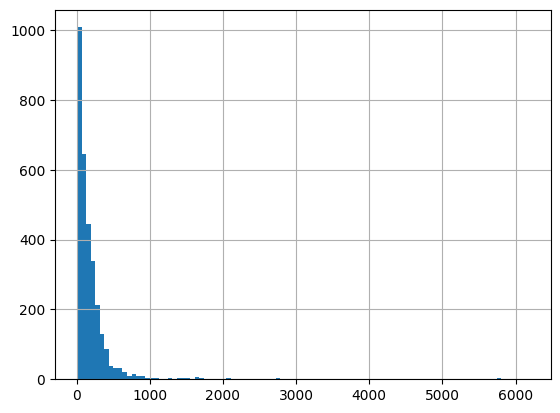

In [17]:
nc_regions_df['length'].hist(bins=100)

In [18]:
def split_intervals_greater_than_n(row, n):
    print(row)
    if row.length <= n:
        return pd.DataFrame([row])
    edges = np.arange(row.Start, row.End, n)
    if edges[-1] < row.End:
        edges = np.append(edges, row.End)
    return pd.DataFrame({
        'Chromosome': [row.Chromosome] * (len(edges) - 1),
        'Start': edges[:-1],
        'End': edges[1:]
    })

In [19]:
nc_regions_df_split = nc_regions_df.apply(split_intervals_greater_than_n, n=1024, axis=1)

Chromosome    Chromosome
Start                  0
End                  189
length               189
Name: 0, dtype: object
Chromosome    Chromosome
Start                255
End                  336
length                81
Name: 1, dtype: object
Chromosome    Chromosome
Start               5020
End                 5233
length               213
Name: 3, dtype: object
Chromosome    Chromosome
Start               5530
End                 5682
length               152
Name: 4, dtype: object
Chromosome    Chromosome
Start               6459
End                 6528
length                69
Name: 5, dtype: object
Chromosome    Chromosome
Start               7959
End                 8237
length               278
Name: 6, dtype: object
Chromosome    Chromosome
Start               9191
End                 9305
length               114
Name: 7, dtype: object
Chromosome    Chromosome
Start               9893
End                 9927
length                34
Name: 8, dtype: object
Chromosome    Ch

In [20]:
nc_regions_df_split = pd.concat(nc_regions_df_split.tolist(), ignore_index=True)
nc_regions_df_split

,Chromosome,Start,End,length
0,Chromosome,0,189,189.0
1,Chromosome,255,336,81.0
2,Chromosome,5020,5233,213.0
3,Chromosome,5530,5682,152.0
4,Chromosome,6459,6528,69.0
...,...,...,...,...
3236,Chromosome,4638120,4638177,57.0
3237,Chromosome,4639530,4639589,59.0
3238,Chromosome,4640306,4640401,95.0
3239,Chromosome,4640542,4640941,399.0


In [21]:
strands = pd.DataFrame({'Strand': ['+', '-']})

In [22]:
nc_regions_df = pd.merge(nc_regions_df_split, strands, how='cross')
nc_regions_df

,Chromosome,Start,End,length,Strand
0,Chromosome,0,189,189.0,+
1,Chromosome,0,189,189.0,-
2,Chromosome,255,336,81.0,+
3,Chromosome,255,336,81.0,-
4,Chromosome,5020,5233,213.0,+
...,...,...,...,...,...
6477,Chromosome,4640306,4640401,95.0,-
6478,Chromosome,4640542,4640941,399.0,+
6479,Chromosome,4640542,4640941,399.0,-
6480,Chromosome,4641628,4641652,24.0,+


In [23]:
import torch
from rinalmo.pretrained import get_pretrained_model

device = "cuda:0"

In [24]:
model, alphabet = get_pretrained_model(model_name="giga-v1")
model = model.to(device=device)
model.eval()
seqs = ["ACUUUGGCCA", "CCCGGU", "ACGU"]

tokens = torch.tensor(alphabet.batch_tokenize(seqs), dtype=torch.int64, device=device)

In [25]:
nuc_table = {"A" : 0, "C":1, "G":2, "U":3} # For RINALMo we have Us instead of Ts

def mutate_sequence(seq):
    seq = seq.upper()
    mutated_sequences = {'seq':[], 'mutation_pos':[], 'nuc':[], 'var_nt_idx':[]} #,'gene_id': []}
    #mutated_sequences['gene_id'].append(gene_id)
    mutated_sequences['seq'].append(seq)
    mutated_sequences['mutation_pos'].append(-1)
    mutated_sequences['nuc'].append('real sequence')
    mutated_sequences['var_nt_idx'].append(-1)


    mutate_until_position = len(seq)

    for i in range(mutate_until_position):
        for nuc in ['A', 'C', 'G', 'U']:
            if nuc != seq[i]:
                #mutated_sequences['gene_id'].append(gene_id)
                mutated_sequences['seq'].append(seq[:i] + nuc + seq[i+1:])
                mutated_sequences['mutation_pos'].append(i)
                mutated_sequences['nuc'].append(nuc)
                mutated_sequences['var_nt_idx'].append(nuc_table[nuc])

    mutations_df = pd.DataFrame(mutated_sequences)

    return mutations_df

In [26]:
import torch
from torch.utils.data import Dataset, DataLoader

class RNADataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]

def custom_collate_fn(batch):

    # batch is a list of sequences
    tokenized_batch = torch.tensor(alphabet.batch_tokenize(batch), 
                                   dtype=torch.int64, 
                                   device=device)
    return tokenized_batch

batch_size = 64

def create_dataloader(dataset, batch_size=batch_size):
    rna_dataset = RNADataset(list(dataset['seq'].values))
    data_loader = DataLoader(rna_dataset, 
                            batch_size=batch_size, 
                            shuffle=False,
                            collate_fn=custom_collate_fn)
    return data_loader

In [27]:
acgu_idxs = [5, 6, 7, 8]
def model_inference(model, data_loader):

    print(f'Inferencing {len(data_loader)} batches')
    output_arrays = []
    for i, batch_tokens in enumerate(data_loader):
        # get some tokenized sequences (B, L_in)
        
        with torch.no_grad(), torch.cuda.amp.autocast():
            outputs = model(batch_tokens)['logits'].cpu().to(torch.float32)
        output_probs = torch.nn.functional.softmax(outputs, dim=-1)[:,:,acgu_idxs] # B, L_seq, 4
        output_arrays.append(output_probs) 

    print(f'Inferencing done')

    # rebuild to nseqs, L_seq, 4
    snp_reconstruct = torch.concat(output_arrays, axis=0)

    return snp_reconstruct.to(torch.float32).numpy()

In [28]:
def compute_ci_matrix(gene_seq,  get_logit=True, effect_on_ref_only = False):

    dataset = mutate_sequence(gene_seq) 
    data_loader = create_dataloader(dataset)
    snp_reconstruct = model_inference(model, data_loader)
    snp_reconstruct = snp_reconstruct[:,1:-1,:] # discard the beginning of sentence token and end of sentence token
    print(snp_reconstruct.shape)

    non_zero_log_value = 1e-10 #due to the conversion to bfloat16, we need to add a small value to avoid log(0)

    if get_logit: # for the logit add the small value and renormalize such that every prob in one position sums to 1
        snp_reconstruct = snp_reconstruct + non_zero_log_value
        snp_reconstruct = snp_reconstruct/snp_reconstruct.sum(axis=-1)[:,:, np.newaxis]

    seq_len = snp_reconstruct.shape[1]
    snp_effect = np.zeros((seq_len, seq_len,4, 4))
    reference_probs = snp_reconstruct[dataset[dataset['nuc'] == 'real sequence'].index[0]]

    print('shape of the reference probs:', reference_probs.shape)

    if get_logit:
        snp_effect[dataset.iloc[1:]['mutation_pos'].values, : ,  dataset.iloc[1:]['var_nt_idx'].values,:] = np.log2(snp_reconstruct[1:]) - np.log2(1 - snp_reconstruct[1:]) \
            - np.log2(reference_probs) + np.log2(1-reference_probs)
    else:
        snp_effect[dataset.iloc[1:]['mutation_pos'].values, : ,  dataset.iloc[1:]['var_nt_idx'].values,:] = np.log2(snp_reconstruct[1:]+non_zero_log_value) - np.log2(reference_probs+non_zero_log_value)

    if effect_on_ref_only:
        gene_seq_int = dataset.iloc[1:].groupby('mutation_pos').apply(lambda pos_df: (set(range(4)) - set(pos_df['var_nt_idx'])).pop()).values
        snp_effect_on_ref = snp_effect[:,np.arange(seq_len),:, gene_seq_int]
        ci_matrix = np.max(np.abs(snp_effect_on_ref), axis=2)

    else:
        ci_matrix = np.max(np.abs(snp_effect), axis=(2,3))

    return ci_matrix

def plot_ci_matrix(ci_matrix, vmax=8, figsize=[10, 10], model="",
                   source_species="", gene_id="",
                   target_species="", homolog="", outfile=None, verbose=False):#increase figure size
    plt.rcParams['figure.figsize'] = figsize
    plt.imshow(ci_matrix, cmap="coolwarm", vmax=vmax) if vmax is not None else plt.imshow(ci_matrix, cmap="coolwarm")
    if verbose:
        plt.title(f"Model: {model}\nSource: {source_species} {gene_id}\nTarget: {target_species} {homolog}",fontsize=20)
    else:
        plt.title(f"Gene ID: {gene_id}",fontsize=20)
    if outfile:
        plt.savefig(outfile, bbox_inches="tight")
    plt.show()
    # return plt

In [29]:
nc_regions_df

,Chromosome,Start,End,length,Strand
0,Chromosome,0,189,189.0,+
1,Chromosome,0,189,189.0,-
2,Chromosome,255,336,81.0,+
3,Chromosome,255,336,81.0,-
4,Chromosome,5020,5233,213.0,+
...,...,...,...,...,...
6477,Chromosome,4640306,4640401,95.0,-
6478,Chromosome,4640542,4640941,399.0,+
6479,Chromosome,4640542,4640941,399.0,-
6480,Chromosome,4641628,4641652,24.0,+


In [29]:
nc_regions_pr = pr.PyRanges(nc_regions_df)

In [30]:
nc_regions_pr.seq = pr.get_sequence(nc_regions_pr, path=fasta_path)
nc_regions_pr

,Chromosome,Start,End,length,Strand,seq
0,Chromosome,0,189,189.0,+,AGCTTTTCATTCTGACTGCAACGGGCAATATGTCTCTGTGTGGATT...
1,Chromosome,255,336,81.0,+,CGCGTACAGGAAACACAGAAAAAAGCCCGCACCTGACAGTGCGGGC...
2,Chromosome,5020,5233,213.0,+,AATCTATTCATTATCTCAATCAGGCCGGGTTTGCTTTTATGCAGCC...
3,Chromosome,5530,5682,152.0,+,ATGACAAATGCCGGGTAACAATCCGGCATTCAGCGCCTGATGCGAC...
4,Chromosome,6459,6528,69.0,+,ATCCAGTCCTTGCAGGAAATTTATGCCGACTTTAGCAAAAAATGAG...
...,...,...,...,...,...,...
6477,Chromosome,4638120,4638177,57.0,-,AGTCTTCTCCTTTGCAATGGCAGCAGGATACGAAGACTATGTGGGA...
6478,Chromosome,4639530,4639589,59.0,-,TCGGCTTTACCACCGTCAAAAAAAACGGCGCTTTTTAGCGCCGTTT...
6479,Chromosome,4640306,4640401,95.0,-,GTTACGCCGATCATGTTAATTTGCAGCATGCATCAGGCAGGTCAGG...
6480,Chromosome,4640542,4640941,399.0,-,ATTGCCACTCTTCTTGATCAAATAACCGCGAACCGGGTGATCACTG...


In [31]:
nc_regions_df = nc_regions_pr.df

In [32]:
nc_regions_df['length'] = nc_regions_df.End - nc_regions_df.Start

In [34]:
nc_regions_df[nc_regions_df['length'] > 1024]

,Chromosome,Start,End,length,Strand,seq


In [35]:
import tqdm 
folder_output = os.path.join(data_path, "ecoli_dms_processed_data/nc_regions_windows_less_eq_1024")

if not os.path.exists(folder_output):
    os.mkdir(folder_output)

for index, row in tqdm.tqdm(nc_regions_df.iterrows()):
    
    sequence = row["seq"].replace('T', 'U').upper()
    region_id = f"{row['Chromosome']}_{row['Start']}_{row['End']}_{row['Strand']}"
    
    file_npy = os.path.join(folder_output, f"{region_id}.npy")
    if not os.path.exists(file_npy):
        
        ci_matrix = compute_ci_matrix(sequence)
        np.save(file_npy, ci_matrix)
        

2339it [00:00, 7864.40it/s]

Inferencing 35 batches


2339it [00:19, 7864.40it/s]

Inferencing done
(2227, 742, 4)
shape of the reference probs: (742, 4)


3055it [01:03, 30.44it/s]  

...

Inferencing done
(97, 32, 4)
shape of the reference probs: (32, 4)
Inferencing 2 batches


5333it [6:35:58,  6.66s/it]

Inferencing done
(106, 35, 4)
shape of the reference probs: (35, 4)
Inferencing 43 batches
Inferencing done
(2722, 907, 4)
shape of the reference probs: (907, 4)


5334it [6:37:27, 31.37s/it]

Inferencing 16 batches
